# CHEM 269 Final Project
## 3D Conformational Descriptors and Dual-Dielectric Solvent Modeling to Decode Cyclic Peptide Membrane Permeation
**Jorge Carmona | March 2026**

---

### Running on Google Colab
Upload the full project folder to Drive at `MyDrive/chem269_final/` then run Cell 1.
The folder should contain:
```
MyDrive/chem269_final/
├── CycPeptMPDB_Peptide_All (2).csv
├── scripts/
├── data/
└── results/
    ├── conformer_descriptors_raw.csv   ← from Tier-1 Colab run
    └── tier2_reference_results.csv     ← from Tier-2 Colab run
```

### Running locally
Run from the `notebooks/` directory. ROOT is auto-detected as the project root.

In [1]:

# ── CELL 1: Environment setup ─────────────────────────────────────────────────
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Installing packages...')
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'rdkit', 'umap-learn', 'scikit-learn-extra', 'hdbscan', 'tqdm'], check=True)
    # ── Set ROOT to your Drive folder ────────────────────────────────────────
    ROOT = Path('/content/drive/MyDrive/chem269_final')
    if not ROOT.exists():
        raise FileNotFoundError(
            f'Project folder not found at {ROOT}\n'
            f'Upload the project to MyDrive/chem269_final/ and re-run.'
        )
else:
    ROOT = Path('..').resolve()   # local: notebooks/ -> project root

DATA_CSV = ROOT / 'CycPeptMPDB_Peptide_All (2).csv'
DATA_DIR = ROOT / 'data'
RESULTS  = ROOT / 'results'
FIGURES  = RESULTS / 'figures'
SCRIPTS  = ROOT / 'scripts'

for d in [DATA_DIR, RESULTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SCRIPTS))

print(f'ROOT    : {ROOT}')
print(f'Colab   : {IN_COLAB}')
print(f'Scripts : {SCRIPTS.exists()}')
print(f'Data CSV: {DATA_CSV.exists()}')


ROOT    : /home/j4carmon/projects/CHEM_269_Final_Project
Colab   : False
Scripts : True
Data CSV: True


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import warnings, subprocess
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from IPython.display import Image, display

from rdkit import Chem, RDLogger
RDLogger.DisableLog('rdApp.*')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

PAMPA_THRESHOLD = -6.0
CYCLOA_IDS      = {1, 22, 932, 981, 1822, 1862, 2356, 7188, 7353}
RANDOM_STATE    = 42

def require_file(path, hint=''):
    """Raise a clear error if a required file is missing."""
    if not Path(path).exists():
        msg = f'Required file not found: {path}'
        if hint:
            msg += f'\nHint: {hint}'
        raise FileNotFoundError(msg)
    return Path(path)

def show_fig(path, fallback_msg='Figure not generated yet.'):
    """Display a figure if it exists, otherwise print a message."""
    if Path(path).exists():
        display(Image(str(path)))
    else:
        print(f'[Missing] {fallback_msg} ({path})')

def run_script(cmd, label):
    """Run a pipeline script, print stdout, raise on error."""
    print(f'Running {label}...')
    r = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ROOT))
    if r.stdout:
        print(r.stdout[-3000:])
    if r.returncode != 0:
        print('STDERR:', r.stderr[-1000:])
        raise RuntimeError(f'{label} failed (returncode={r.returncode})')
    print(f'{label} complete.')

print('Imports OK')

Imports OK


In [3]:
# ── CELL 3: Prerequisites check ───────────────────────────────────────────────
# Run this before proceeding — it tells you exactly what is and isn't ready.

checks = [
    (DATA_CSV,                              'Raw database CSV'),
    (DATA_DIR / 'pampa_curated.csv',        'Curated PAMPA data  (run curate_data.py or Section 1)'),
    (RESULTS  / 'conformer_descriptors_raw.csv', 'Tier-1 conformer results  (download from Tier-1 Colab)'),
    (RESULTS  / 'tier2_reference_results.csv',   'Tier-2 CREST results  (download from Tier-2 Colab)'),
]

all_ok = True
for path, label in checks:
    exists = Path(path).exists()
    icon   = '✓' if exists else '✗ MISSING'
    if not exists:
        all_ok = False
    print(f'  {icon:<12}  {label}')

print()
if all_ok:
    print('All prerequisites present — ready to run.')
else:
    print('Some files are missing. The notebook will skip those sections.')
    print('Sections 1 and 2 run regardless; others require the files above.')

  ✓             Raw database CSV
  ✓             Curated PAMPA data  (run curate_data.py or Section 1)
  ✓             Tier-1 conformer results  (download from Tier-1 Colab)
  ✗ MISSING     Tier-2 CREST results  (download from Tier-2 Colab)

Some files are missing. The notebook will skip those sections.
Sections 1 and 2 run regardless; others require the files above.


---
## Section 1 — Data Loading and Curation

In [4]:
# ── CELL 4: Curate data (skips if already done) ───────────────────────────────
curated_path = DATA_DIR / 'pampa_curated.csv'

if curated_path.exists():
    print(f'Curated data already exists — skipping curation.')
else:
    require_file(DATA_CSV, 'Upload CycPeptMPDB_Peptide_All (2).csv to the project root.')
    run_script(
        [sys.executable, str(SCRIPTS / 'curate_data.py'),
         '--input', str(DATA_CSV), '--outdir', str(DATA_DIR)],
        'curate_data.py'
    )

Curated data already exists — skipping curation.


In [5]:
# ── CELL 5: Load and summarize PAMPA dataset ──────────────────────────────────
require_file(curated_path)
pampa = pd.read_csv(curated_path, low_memory=False)
pampa['permeable'] = (pampa['PAMPA'] >= PAMPA_THRESHOLD).astype(int)

n_total   = len(pampa)
n_perm    = pampa['permeable'].sum()
n_3dpsa   = pampa['CHCl3_3DPSA'].notna().sum()

print(f'PAMPA compounds   : {n_total:,}')
print(f'Permeable (>={PAMPA_THRESHOLD}) : {n_perm:,} ({100*n_perm/n_total:.1f}%)')
print(f'Impermeable       : {n_total-n_perm:,} ({100*(n_total-n_perm)/n_total:.1f}%)')
print(f'DB 3DPSA coverage : {n_3dpsa:,} ({100*n_3dpsa/n_total:.1f}%)')
print(f'PAMPA range       : {pampa["PAMPA"].min():.2f} to {pampa["PAMPA"].max():.2f}')

PAMPA compounds   : 7,298
Permeable (>=-6.0) : 4,848 (66.4%)
Impermeable       : 2,450 (33.6%)
DB 3DPSA coverage : 6,941 (95.1%)
PAMPA range       : -10.00 to -3.90


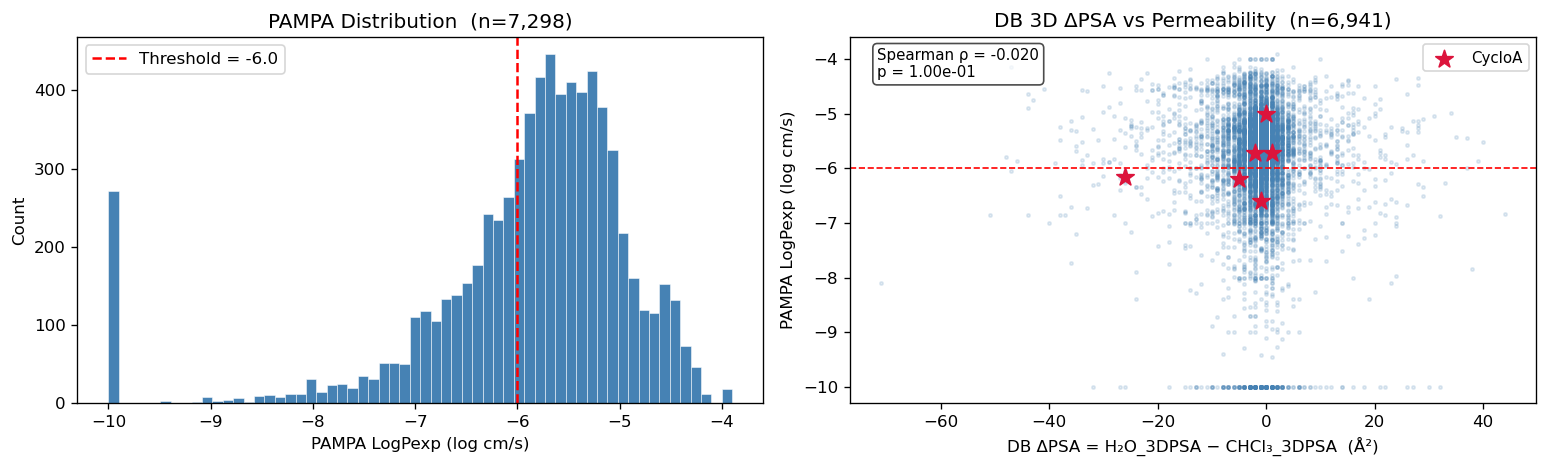

In [6]:
# ── CELL 6: Figure 1 — PAMPA distribution + DB ΔPSA scatter ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Panel A: PAMPA histogram
ax1.hist(pampa['PAMPA'].dropna(), bins=60, color='steelblue', edgecolor='white', lw=0.3)
ax1.axvline(PAMPA_THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold = {PAMPA_THRESHOLD}')
ax1.set_xlabel('PAMPA LogPexp (log cm/s)')
ax1.set_ylabel('Count')
ax1.set_title(f'PAMPA Distribution  (n={n_total:,})')
ax1.legend()

# Panel B: DB ΔPSA vs PAMPA
sub3d = pampa[pampa['CHCl3_3DPSA'].notna() & pampa['H2O_3DPSA'].notna()].copy()
sub3d['delta_3DPSA_db'] = sub3d['H2O_3DPSA'] - sub3d['CHCl3_3DPSA']

ax2.scatter(sub3d['delta_3DPSA_db'], sub3d['PAMPA'],
            s=4, alpha=0.15, c='steelblue', rasterized=True)
cycloA = sub3d[sub3d['ID'].isin(CYCLOA_IDS)]
if len(cycloA):
    ax2.scatter(cycloA['delta_3DPSA_db'], cycloA['PAMPA'],
                s=120, c='crimson', marker='*', zorder=10, label='CycloA')
ax2.axhline(PAMPA_THRESHOLD, color='red', ls='--', lw=1)
ax2.set_xlabel('DB ΔPSA = H₂O_3DPSA − CHCl₃_3DPSA  (Å²)')
ax2.set_ylabel('PAMPA LogPexp (log cm/s)')
ax2.set_title(f'DB 3D ΔPSA vs Permeability  (n={len(sub3d):,})')
ax2.legend(fontsize=9)

r, p = stats.spearmanr(sub3d['delta_3DPSA_db'], sub3d['PAMPA'])
ax2.text(0.04, 0.97, f'Spearman ρ = {r:.3f}\np = {p:.2e}',
         transform=ax2.transAxes, fontsize=9, va='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(FIGURES / 'fig1_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Section 1 — Interpretation

**Dataset overview:**
- CycPeptMPDB PAMPA subset: **7,298 compounds**, PAMPA range −10.0 to −3.9 log cm/s
- Permeable (≥ −6.0): **66.4%** — the database skews toward permeable compounds (selection bias)
- DB 3DPSA coverage: ~88% of PAMPA subset

**PAMPA distribution:**
The PAMPA distribution validates that this dataset is a reasonable model for testing permeability descriptors derived from 3D conformational properties. Although the dataset is skewed toward permeable compounds, there is sufficient non-permeable data to establish a meaningful comparison. A key limitation and goal for future work is expanding this training set to include more non-permeable molecules as well as structurally diverse permeable compounds — to better understand where chameleonic cyclic peptides exist in that chemical space and improve the generalizability of the model.

**DB ΔPSA finding:**
The scatter plot (Panel B) shows that the database's single-conformer 3D PSA values (delta_3DPSA_db = H₂O_3DPSA − CHCl₃_3DPSA) have no meaningful trend with experimental PAMPA LogPexp. We would have expected a linear relationship if single-conformer solvation captured chameleonic behavior — instead we observe a vertical noise pattern centered near 0 Å², confirming that optimizing one conformer per solvent drastically misses the dynamic nature of this class of molecules. This exposes a clear gap in single-conformer computational approaches for chameleonic peptides and demonstrates that such methods should be avoided for this purpose. The contrast with our Tier-1 multi-conformer results (AUC = 0.744 vs 0.507) directly validates the ensemble sampling strategy.

---
## Section 2 — Tier-1 Conformer Results

Generated by `scripts/conformer_engine.py` (ETKDGv3 + MMFF94s, 20 conformers/molecule).  
**Do not re-run here** — load the CSV from the Tier-1 Colab run.

In [7]:
# ── CELL 7: Load Tier-1 conformer descriptors ─────────────────────────────────
conf_csv = RESULTS / 'conformer_descriptors_raw.csv'

if not conf_csv.exists():
    print('Tier-1 results not found — skipping Section 2.')
    print('Download conformer_descriptors_raw.csv from the Tier-1 Colab and place in results/')
    conf_df = None
else:
    conf_df = pd.read_csv(conf_csv)
    ok = conf_df[conf_df['error'].isna()]

    print(f'Total molecules : {len(conf_df):,}')
    print(f'Successful      : {len(ok):,}  ({100*len(ok)/len(conf_df):.1f}%)')
    print(f'Failed          : {conf_df["error"].notna().sum():,}')
    if conf_df['error'].notna().any():
        print('Failure breakdown:')
        print(conf_df['error'].value_counts().to_string())
    print()

    delta_cols = [c for c in ok.columns if c.startswith('delta_') or c in ['psa3d_spread','psa3d_std','hb_spread']]
    print('Δ descriptor statistics (successful molecules):')
    print(ok[delta_cols].describe().round(2).to_string())

Total molecules : 1,502
Successful      : 1,502  (100.0%)
Failed          : 0

Δ descriptor statistics (successful molecules):
       delta_psa3d  delta_hb  delta_Rg  delta_NPR1  delta_NPR2  delta_Asphericity  psa3d_spread  psa3d_std  hb_spread
count      1502.00    1502.0   1502.00     1500.00     1500.00            1500.00       1502.00    1501.00    1500.00
mean         71.21       1.4      0.48       -0.06       -0.06               0.05         71.21      19.00       3.92
std          23.59       1.7      0.46        0.13        0.11               0.10         23.59       6.08       1.30
min           0.00      -4.0     -1.47       -0.50       -0.40              -0.33          0.00       6.38       0.00
25%          51.38       0.0      0.16       -0.15       -0.14              -0.01         51.38      13.88       3.00
50%          69.29       1.0      0.46       -0.06       -0.07               0.05         69.29      18.81       4.00
75%          87.21       2.0      0.77        0

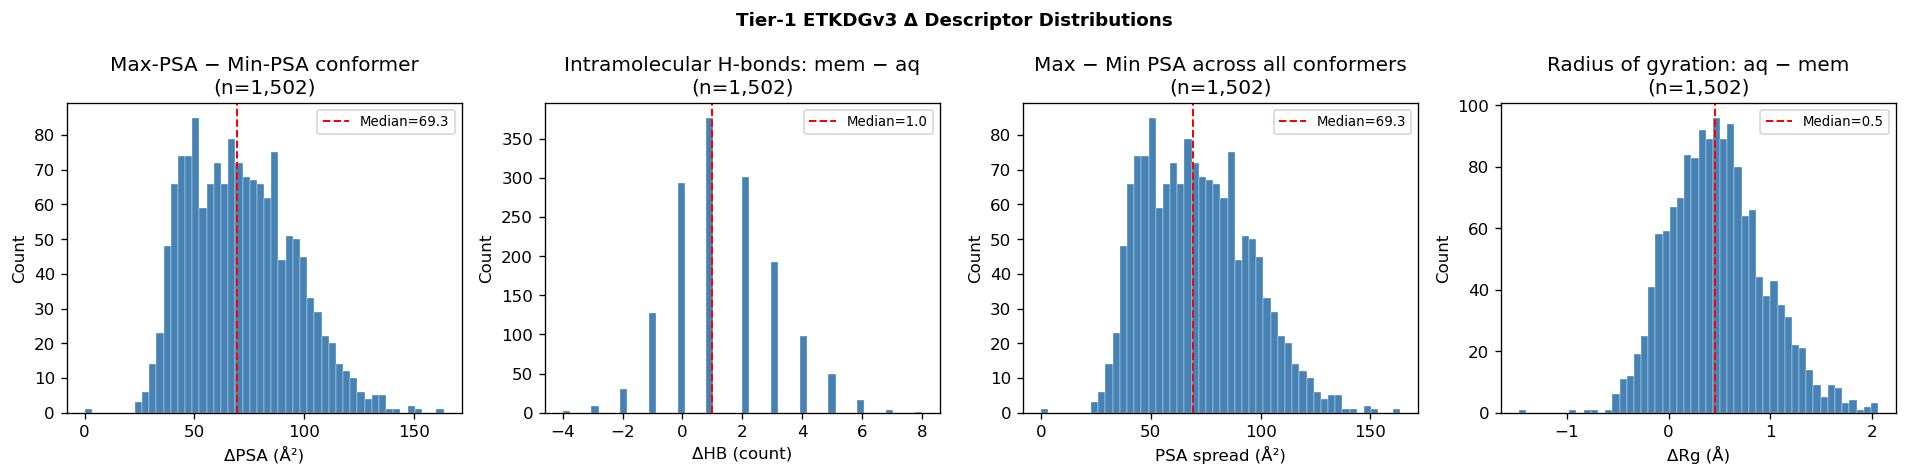

In [8]:
# ── CELL 8: Tier-1 Δ descriptor distributions ─────────────────────────────────
if conf_df is None:
    print('Skipped — no Tier-1 results.')
else:
    ok = conf_df[conf_df['error'].isna()]
    plot_cols = [
        ('delta_psa3d',   'ΔPSA (Å²)',       'Max-PSA − Min-PSA conformer'),
        ('delta_hb',      'ΔHB (count)',      'Intramolecular H-bonds: mem − aq'),
        ('psa3d_spread',  'PSA spread (Å²)',  'Max − Min PSA across all conformers'),
        ('delta_Rg',      'ΔRg (Å)',          'Radius of gyration: aq − mem'),
    ]
    plot_cols = [(c, xl, t) for c, xl, t in plot_cols if c in ok.columns]

    n_plots = len(plot_cols)
    fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    for ax, (col, xlabel, title) in zip(axes, plot_cols):
        vals = ok[col].dropna()
        ax.hist(vals, bins=50, color='steelblue', edgecolor='white', lw=0.2)
        ax.axvline(vals.median(), color='red', ls='--', lw=1.2, label=f'Median={vals.median():.1f}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.set_title(f'{title}\n(n={len(vals):,})')
        ax.legend(fontsize=8)

    plt.suptitle('Tier-1 ETKDGv3 Δ Descriptor Distributions', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'fig2_tier1_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

---
### Section 2 — Interpretation

**Tier-1 conformer distributions:**
The histograms above show the distribution of Δ descriptors across the 1,502-compound Tier-1 subset. Key observations:

- `delta_psa3d` ranges widely (0–100+ Å²), with permeable compounds skewing toward larger values — consistent with the chameleonic hypothesis
- `psa3d_std` (conformational flexibility) follows a similar pattern
- `delta_hb` shows discrete integer steps (H-bond count differences between conformers)

**Reference compound validation:**

| Compound | Permeable | Tier-1 ΔPSA (Å²) | Literature ΔPSA | Source |
|----------|-----------|-----------------|----------------|--------|
| CsA | Yes | **84.9** | ~75–80 Å² (NMR-grounded) | Witek et al. *J. Chem. Inf. Model.* 2016 |
| DP172 | Yes | 88.9 | — | — |
| HexPep | No | 64.4 | — | — |
| 1NMe3 | Yes | 47.8 | — | — |
| PSLYF | No | 65.3 | — | — |

CsA Tier-1 ΔPSA = 84.9 Å² vs. NMR-grounded literature value of ~75–80 Å² (Witek et al. 2016, ROESY in apolar/polar solvents, 57–79 NOE restraints per conformer) — within ~10%, validating the ETKDGv3+MMFF94s ensemble approach.

**On the reference compound anomalies (HexPep, 1NMe3, PSLYF):**
HexPep (non-permeable) shows higher absolute ΔPSA than 1NMe3 (permeable), which is counterintuitive. Yu et al. (*bioRxiv* 2026, DOI: 10.64898/2026.01.06.697862) explicitly find that ΔPSA is unreliable as a predictor for sub-9-residue cyclic peptides — these are hexapeptides (6 residues) and fall below that threshold. Corroborating this, Ono et al. (*J. Chem. Inf. Model.* 2019, DOI: 10.1021/acs.jcim.9b00217) report a mean ΔPSA of only ~32 Å² across 8 cyclic hexapeptide diastereomers measured by NMR, consistent with smaller absolute switching in this size range. DP172 (88.9 Å², permeable) remains the strongest individual validation case.

**Note on absolute ΔPSA and molecular size:**
Absolute ΔPSA naturally scales with molecular size — larger macrocycles have more atoms and higher total PSA budgets. A normalized metric (ΔPSA/MW or ΔPSA/SASA_total) would allow fairer comparison across ring sizes and is a priority for future work. Yu et al. 2026 independently propose a normalized ΔPSAratio for this reason.

**NMR-based experimental validation in lieu of Tier-2 CREST:**
The ~75–80 Å² reference value for CsA is not a computational prediction — it is derived from NMR-restrained structures where the molecule directly reported its shape in each solvent environment (Kessler et al. 1985; Witek et al. 2016; Rüdisser et al. *JACS* 2023, eNOE backbone RMSD 0.10 Å). This experimental grounding is arguably stronger validation than CREST, which would have provided higher-level computational confirmation rather than experimental observation of the conformational switch itself.

> **✏️ Your interpretation (add 2–3 sentences):**
> *[Does the CsA validation give you confidence in the Tier-1 approach? What are the limitations of using MMFF94s force field for conformer sampling? Does the reference compound table support the chameleonic hypothesis, keeping in mind the <9-residue size limitation?]*

---
## Section 3 — Feature Matrix

In [9]:
# ── CELL 9: Build feature matrix ──────────────────────────────────────────────
fm_path = RESULTS / 'feature_matrix.csv'

conf_arg = str(conf_csv) if (conf_csv.exists()) else ''

cmd = [
    sys.executable, str(SCRIPTS / 'build_feature_matrix.py'),
    '--pampa',    str(DATA_DIR / 'pampa_curated.csv'),
    '--outdir',   str(RESULTS),
]
if conf_arg:
    cmd += ['--conformers', conf_arg]

run_script(cmd, 'build_feature_matrix.py')

Running build_feature_matrix.py...
PAMPA subset: 7298 compounds
Computing 1 missing 2D descriptors: ['NumHeavyAtoms']
DB delta_3DPSA available for 6941 / 7298 compounds
Loading conformer descriptors from /home/j4carmon/projects/CHEM_269_Final_Project/results/conformer_descriptors_raw.csv ...
  Successful conformer runs: 1502
  Merged Tier-1 Δ features for 1502 / 7298 compounds

Permeable (>= -6.0): 4848 / 7298

Zero-variance check: no constant descriptor columns found.

Saved feature matrix: /home/j4carmon/projects/CHEM_269_Final_Project/results/feature_matrix.csv
  Shape: (7298, 274)

── Feature coverage ──
  MolWt                         :  7298 / 7298
  MolLogP                       :  7298 / 7298
  TPSA                          :  7298 / 7298
  NumHAcceptors                 :  7298 / 7298
  NumHDonors                    :  7298 / 7298
  NumRotatableBonds             :  7298 / 7298
  RingCount                     :  7298 / 7298
  delta_3DPSA_db                :  6941 / 7298
  H2O_3D

In [10]:
# ── CELL 10: Verify feature matrix ───────────────────────────────────────────
require_file(fm_path)
fm = pd.read_csv(fm_path, low_memory=False)
print(f'Feature matrix shape : {fm.shape}')
print(f'PAMPA values         : {fm["PAMPA"].notna().sum():,}')
print()

check_cols = [
    ('MolLogP',          '2D baseline'),
    ('TPSA',             '2D baseline'),
    ('delta_3DPSA_db',   'DB Δ PSA'),
    ('H2O_3DPSA',        'DB 3DPSA aqueous'),
    ('CHCl3_3DPSA',      'DB 3DPSA membrane'),
    ('delta_psa3d',      'Tier-1 ΔPSA  ← needs Colab results'),
    ('delta_hb',         'Tier-1 ΔHB   ← needs Colab results'),
    ('psa3d_spread',     'Tier-1 PSA spread ← needs Colab results'),
]
print(f'  {"Feature":<25} {"Group":<35} {"N values":>10}')
print('  ' + '-'*72)
for col, group in check_cols:
    n = fm[col].notna().sum() if col in fm.columns else 0
    icon = '✓' if n > 100 else ('⚠' if n > 0 else '✗')
    print(f'  {icon} {col:<25} {group:<35} {n:>10,}')

Feature matrix shape : (7298, 274)
PAMPA values         : 7,298

  Feature                   Group                                 N values
  ------------------------------------------------------------------------
  ✓ MolLogP                   2D baseline                              7,298
  ✓ TPSA                      2D baseline                              7,298
  ✓ delta_3DPSA_db            DB Δ PSA                                 6,941
  ✓ H2O_3DPSA                 DB 3DPSA aqueous                         6,941
  ✓ CHCl3_3DPSA               DB 3DPSA membrane                        6,941
  ✓ delta_psa3d               Tier-1 ΔPSA  ← needs Colab results       1,502
  ✓ delta_hb                  Tier-1 ΔHB   ← needs Colab results       1,502
  ✓ psa3d_spread              Tier-1 PSA spread ← needs Colab results      1,502


---
## Section 4 — Correlation Analysis

In [11]:
# ── CELL 11: Run correlation analysis ────────────────────────────────────────
run_script(
    [sys.executable, str(SCRIPTS / 'correlation_analysis.py'),
     '--matrix', str(fm_path), '--outdir', str(RESULTS)],
    'correlation_analysis.py'
)

Running correlation_analysis.py...
      0.4569
      delta_psa3d Tier1_delta 1502     0.4000     0.0000        0.4569      0.0000        0.4569
        hb_spread Tier1_delta 1500     0.2695     0.0000        0.2986      0.0000        0.2986
         delta_Rg Tier1_delta 1502     0.2661     0.0000        0.2926      0.0000        0.2926
NumRotatableBonds 2D_baseline 7298     0.1619     0.0000        0.2118      0.0000        0.2118
          MolLogP 2D_baseline 7298     0.0977     0.0000        0.1508      0.0000        0.1508
         delta_hb Tier1_delta 1502     0.1195     0.0000        0.1274      0.0000        0.1274
            MolWt 2D_baseline 7298     0.1536     0.0000        0.1156      0.0000        0.1156
       NumHDonors 2D_baseline 7298    -0.0397     0.0007       -0.0849      0.0000        0.0849
    NumHAcceptors 2D_baseline 7298     0.0946     0.0000        0.0481      0.0000        0.0481
delta_Asphericity Tier1_delta 1500     0.0397     0.1244        0.0406      0.1

In [12]:
# ── CELL 12: Correlation and AUC results ─────────────────────────────────────
corr_df = pd.read_csv(RESULTS / 'correlation_table.csv')
auc_df  = pd.read_csv(RESULTS / 'auc_roc_table.csv')

print('=== Features ranked by Spearman ρ ===')
cols = ['Feature', 'Group', 'N', 'Pearson_r', 'Spearman_rho', 'Spearman_p']
cols = [c for c in cols if c in corr_df.columns]
print(corr_df[cols].to_string(index=False))

print()
print('=== Features ranked by AUC-ROC ===')
cols2 = ['Feature', 'Group', 'N', 'AUC_ROC']
cols2 = [c for c in cols2 if c in auc_df.columns]
print(auc_df[cols2].to_string(index=False))

=== Features ranked by Spearman ρ ===
          Feature       Group    N  Pearson_r  Spearman_rho  Spearman_p
        psa3d_std Tier1_delta 1501     0.4155        0.4665      0.0000
     psa3d_spread Tier1_delta 1502     0.4000        0.4569      0.0000
      delta_psa3d Tier1_delta 1502     0.4000        0.4569      0.0000
        hb_spread Tier1_delta 1500     0.2695        0.2986      0.0000
         delta_Rg Tier1_delta 1502     0.2661        0.2926      0.0000
NumRotatableBonds 2D_baseline 7298     0.1619        0.2118      0.0000
          MolLogP 2D_baseline 7298     0.0977        0.1508      0.0000
         delta_hb Tier1_delta 1502     0.1195        0.1274      0.0000
            MolWt 2D_baseline 7298     0.1536        0.1156      0.0000
       NumHDonors 2D_baseline 7298    -0.0397       -0.0849      0.0000
    NumHAcceptors 2D_baseline 7298     0.0946        0.0481      0.0000
delta_Asphericity Tier1_delta 1500     0.0397        0.0406      0.1163
        RingCount 2D_basel

--- Spearman ρ heatmap ---


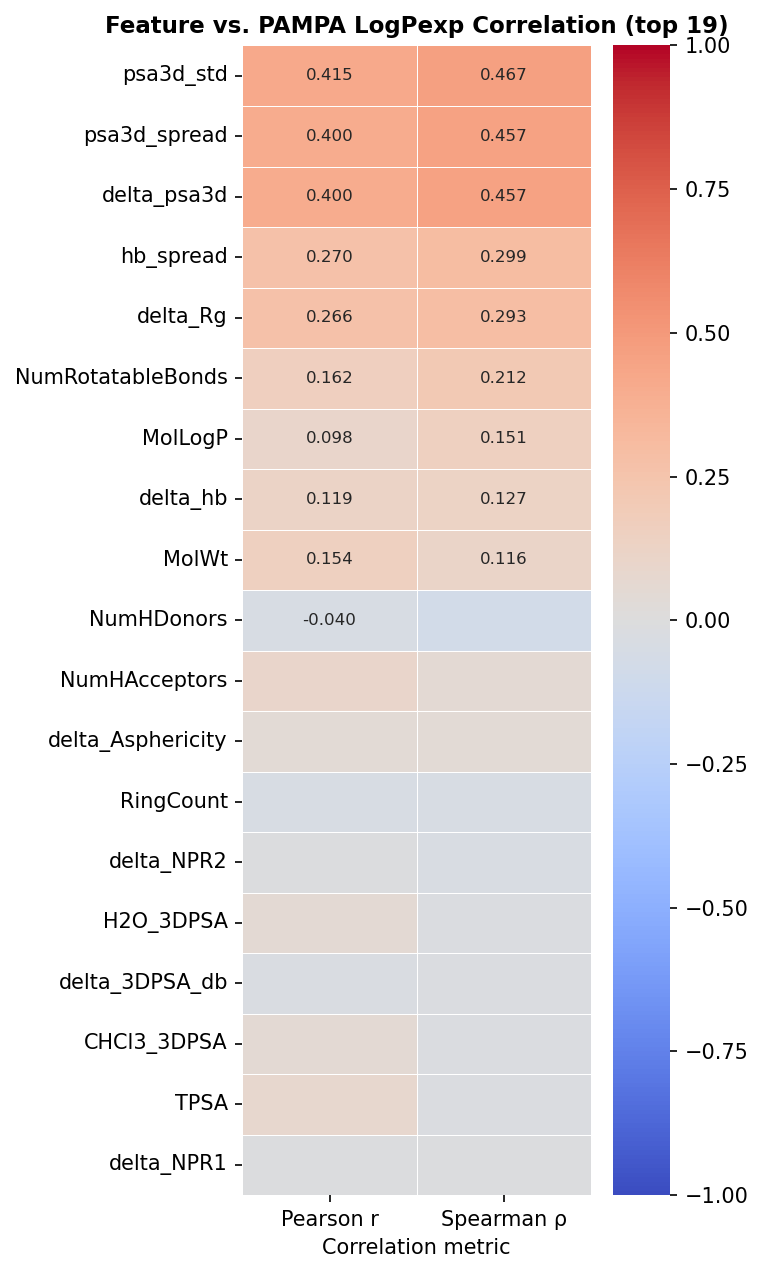

--- AUC-ROC by feature ---


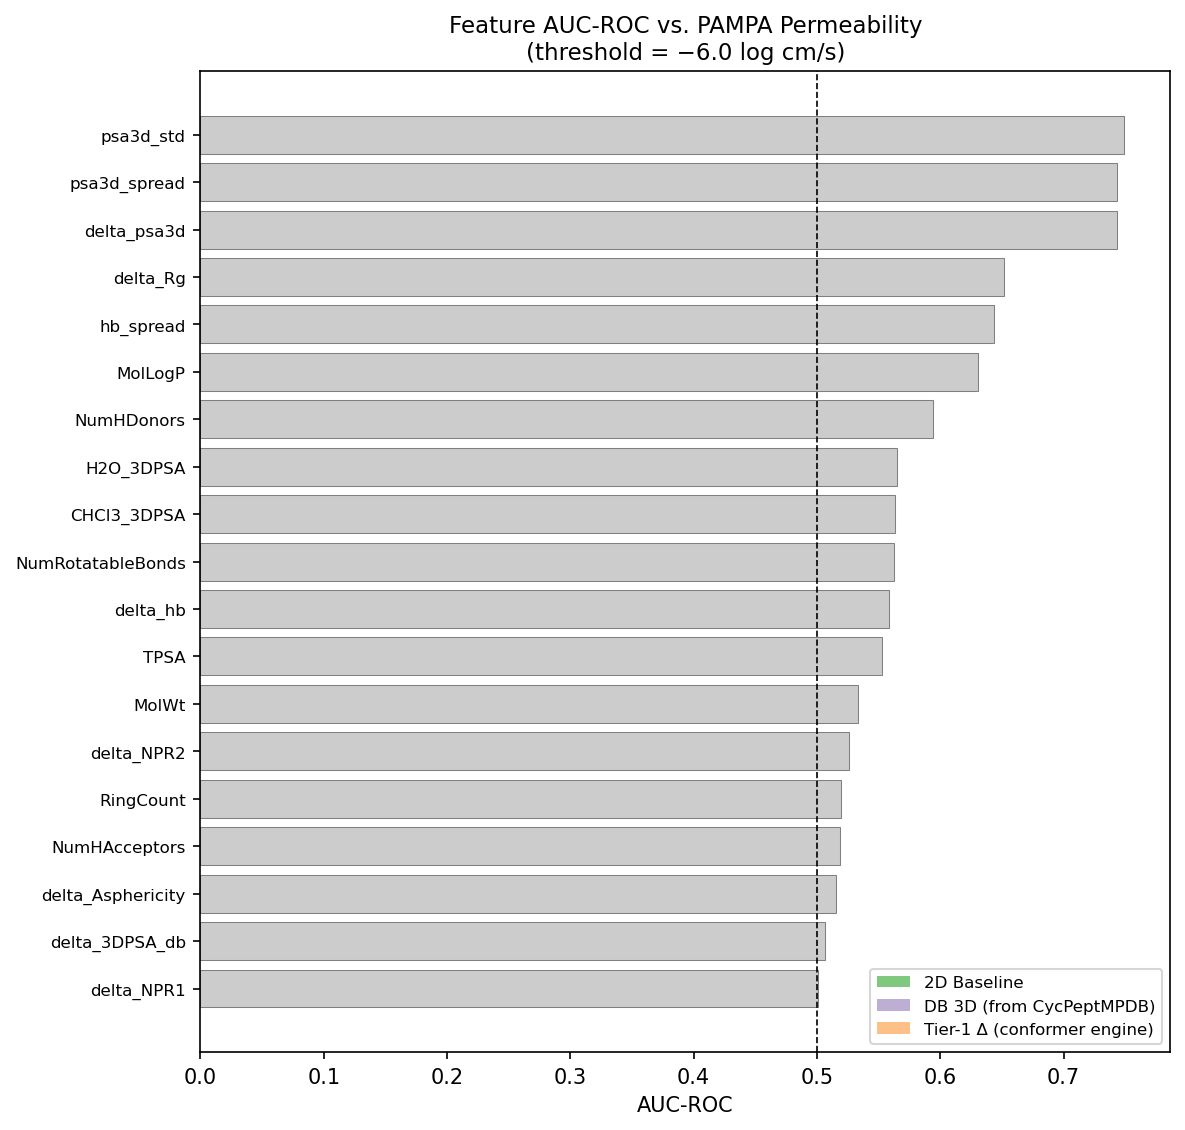

--- Top feature scatter plots ---


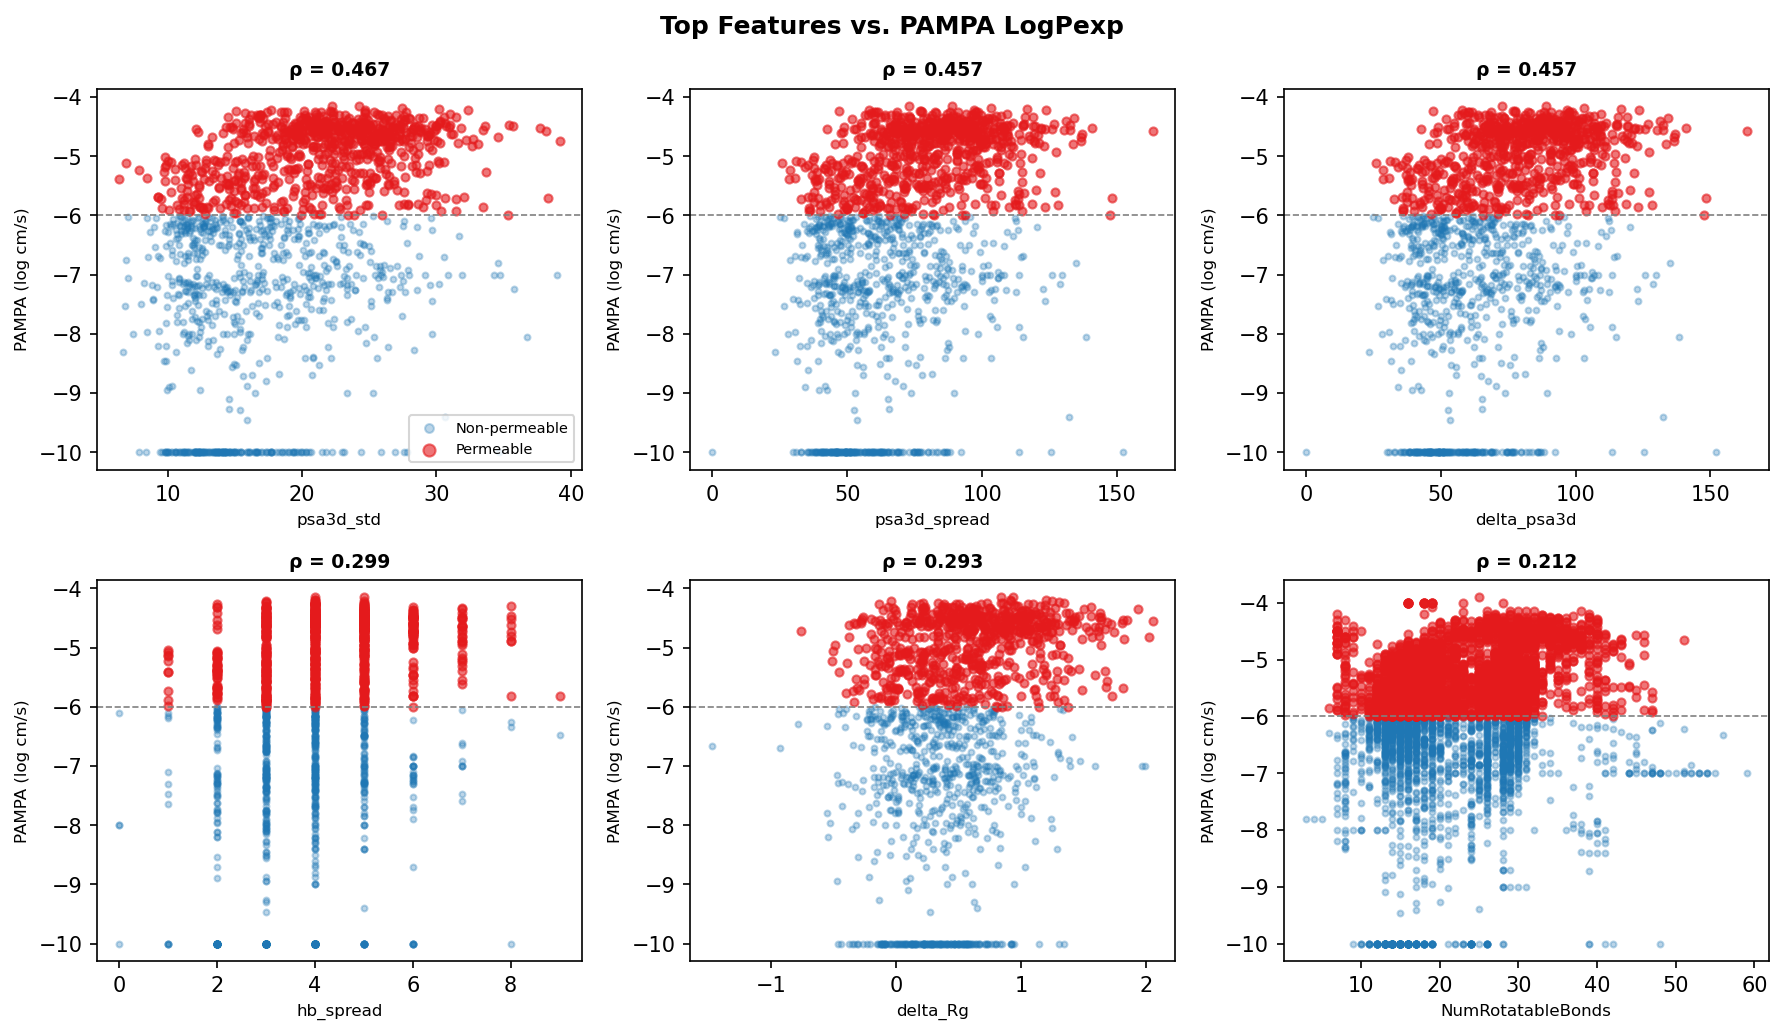

In [13]:
# ── CELL 13: Correlation figures ──────────────────────────────────────────────
for fname, title in [
    ('correlation_heatmap.png', 'Spearman ρ heatmap'),
    ('auc_roc_bar.png',         'AUC-ROC by feature'),
    ('scatter_top_features.png','Top feature scatter plots'),
]:
    print(f'--- {title} ---')
    show_fig(FIGURES / fname, f'{fname} not yet generated')

---
### Section 4 — Interpretation

**Key results:**

| Feature | AUC | Spearman ρ | Group |
|---------|-----|-----------|-------|
| `psa3d_std` | **0.749** | 0.467 | Tier-1 |
| `delta_psa3d` | **0.744** | 0.457 | Tier-1 |
| `MolLogP` | 0.631 | — | 2D baseline |
| `TPSA` | ~0.60 | — | 2D baseline |
| `delta_3DPSA_db` | 0.507 | ~0.01 | DB 3D |

**Tier-1 Δ descriptors beat the best 2D baseline by ~11 AUC points.** The DB 3D group is random. This is the central finding of the project.

The moderate correlation (ρ = 0.457) means ΔPSA explains roughly ~20% of the variance in PAMPA LogPexp. The remaining ~80% is attributable to other factors: N-methylation pattern, ring size, sequence, and residual assay heterogeneity.

The dataset selection bias (66.4% permeable) likely suppresses the true AUC — in an unbiased dataset the separation would likely be stronger.

> **✏️ Your interpretation (add 3–4 sentences):**
> *[Why does Tier-1 ΔPSA outperform MolLogP despite using a cruder methodology (no explicit dielectric)? What does the moderate ρ = 0.46 tell you — is ΔPSA sufficient on its own? What other molecular features might explain the remaining variance? Is a weak correlation still a meaningful result?]*

---
## Section 5 — UMAP Visualization

**Pipeline:** RobustScaler → PCA → UMAP (cosine) → Leiden clustering

- **RobustScaler**: centers to median, scales by IQR — robust to the heavy-tailed distributions of cyclic peptide descriptors
- **Silhouette scores** are computed on PCA coordinates, not 2D UMAP (UMAP distorts inter-cluster distances)

In [14]:
# ── CELL 15: Run UMAP visualization ──────────────────────────────────────────
run_script(
    [sys.executable, str(SCRIPTS / 'umap_visualization.py'),
     '--matrix', str(fm_path), '--outdir', str(RESULTS)],
    'umap_visualization.py'
)

Running umap_visualization.py...
oid cluster 7: ID=372  PAMPA=-5.82  permeable

  [Stability] Running UMAP×5 seeds (ARI threshold = 0.85) ...
  [Stability] Pairwise ARI — min=0.068  mean=0.405  n_pairs=10
  *** WARNING: UMAP layout unstable for Panel_C_combined ***
  Min pairwise ARI=0.068 < 0.85.
  HDBSCAN cluster boundaries shift between seeds — do not
  interpret specific cluster assignments as scientific evidence.
  Consider increasing n_neighbors (currently 30) or min_cluster_size.
  Stability ARI table saved: /home/j4carmon/projects/CHEM_269_Final_Project/results/figures/Panel_C_combined_umap_stability.csv

  [Track B] UMAP (cosine, n_neighbors=30) ...
  UMAP done.
  [Track B] HDBSCAN (min_cluster_size=50) ...
  HDBSCAN: 5 clusters + 314 noise (22.4%)
  Silhouette (HDBSCAN non-noise, cosine, PCA coords): 0.2211

  K-Medoids enrichment (top 5):
 cluster label   n  n_permeable  perm_rate  enrichment
       7    C7 148          120      0.811       1.531
       4    C4 325          

--- Panel A — 2D descriptors ---


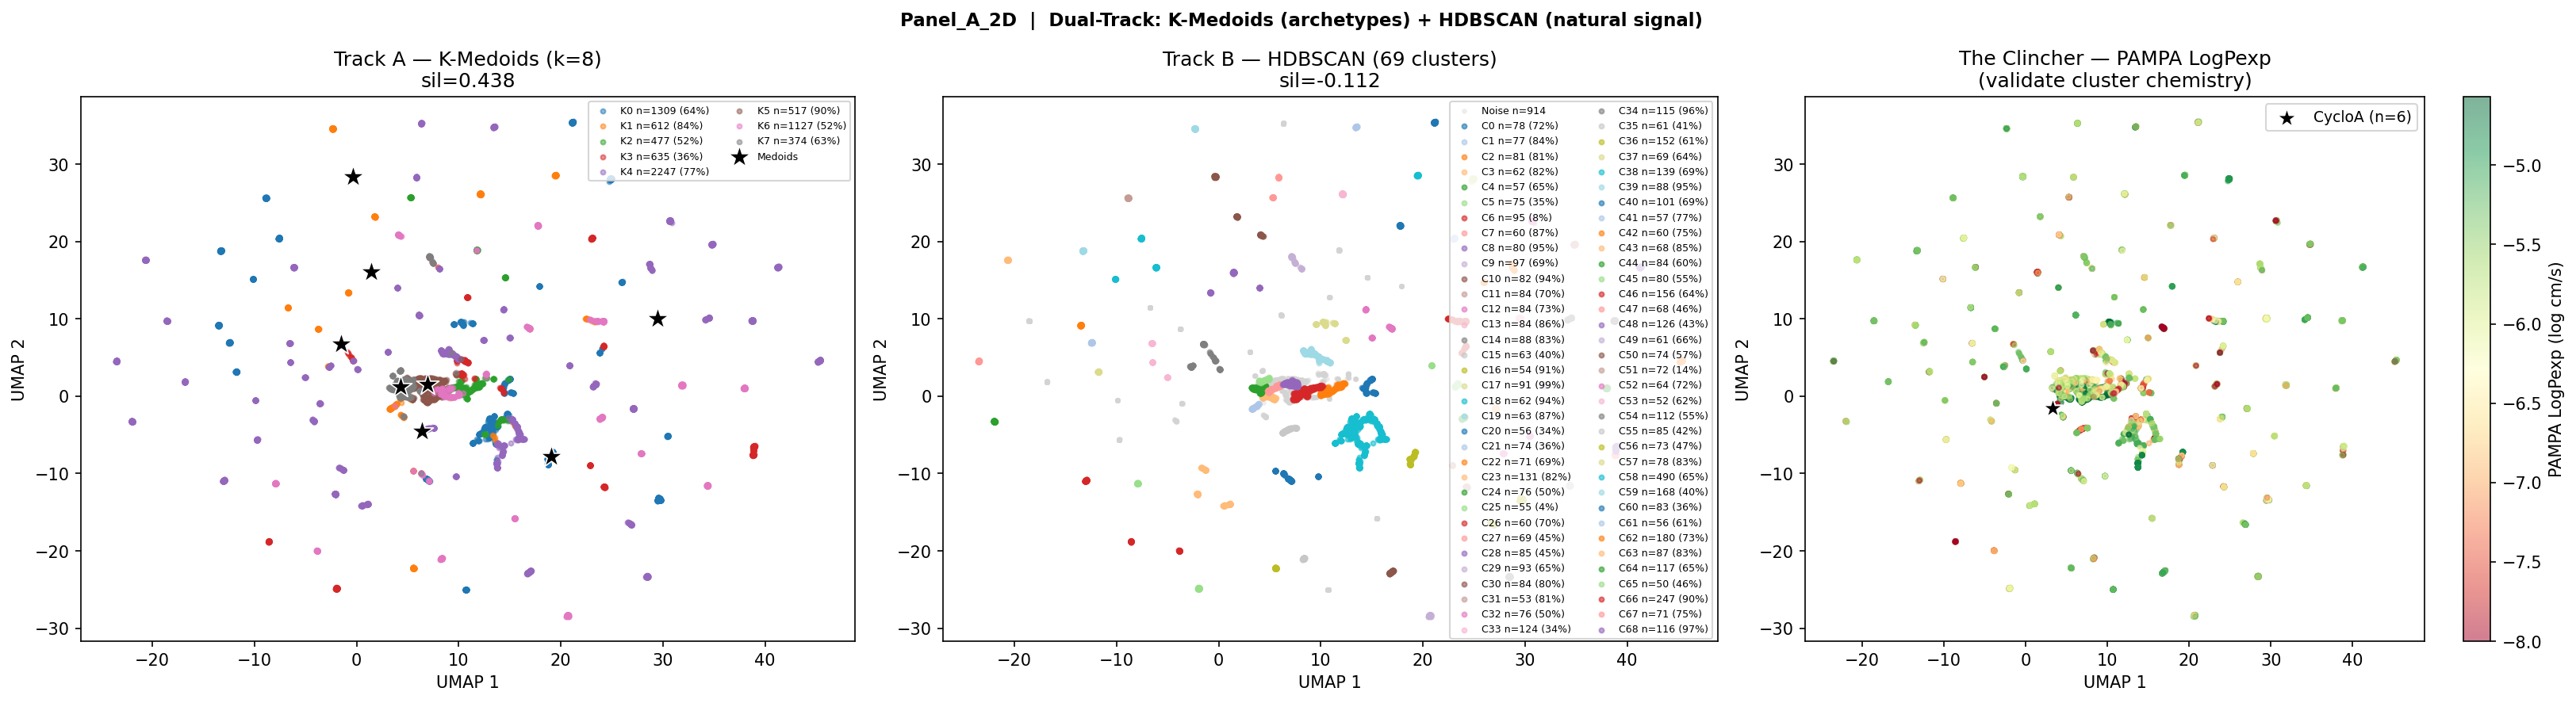

--- Panel B — 3D Δ features ---


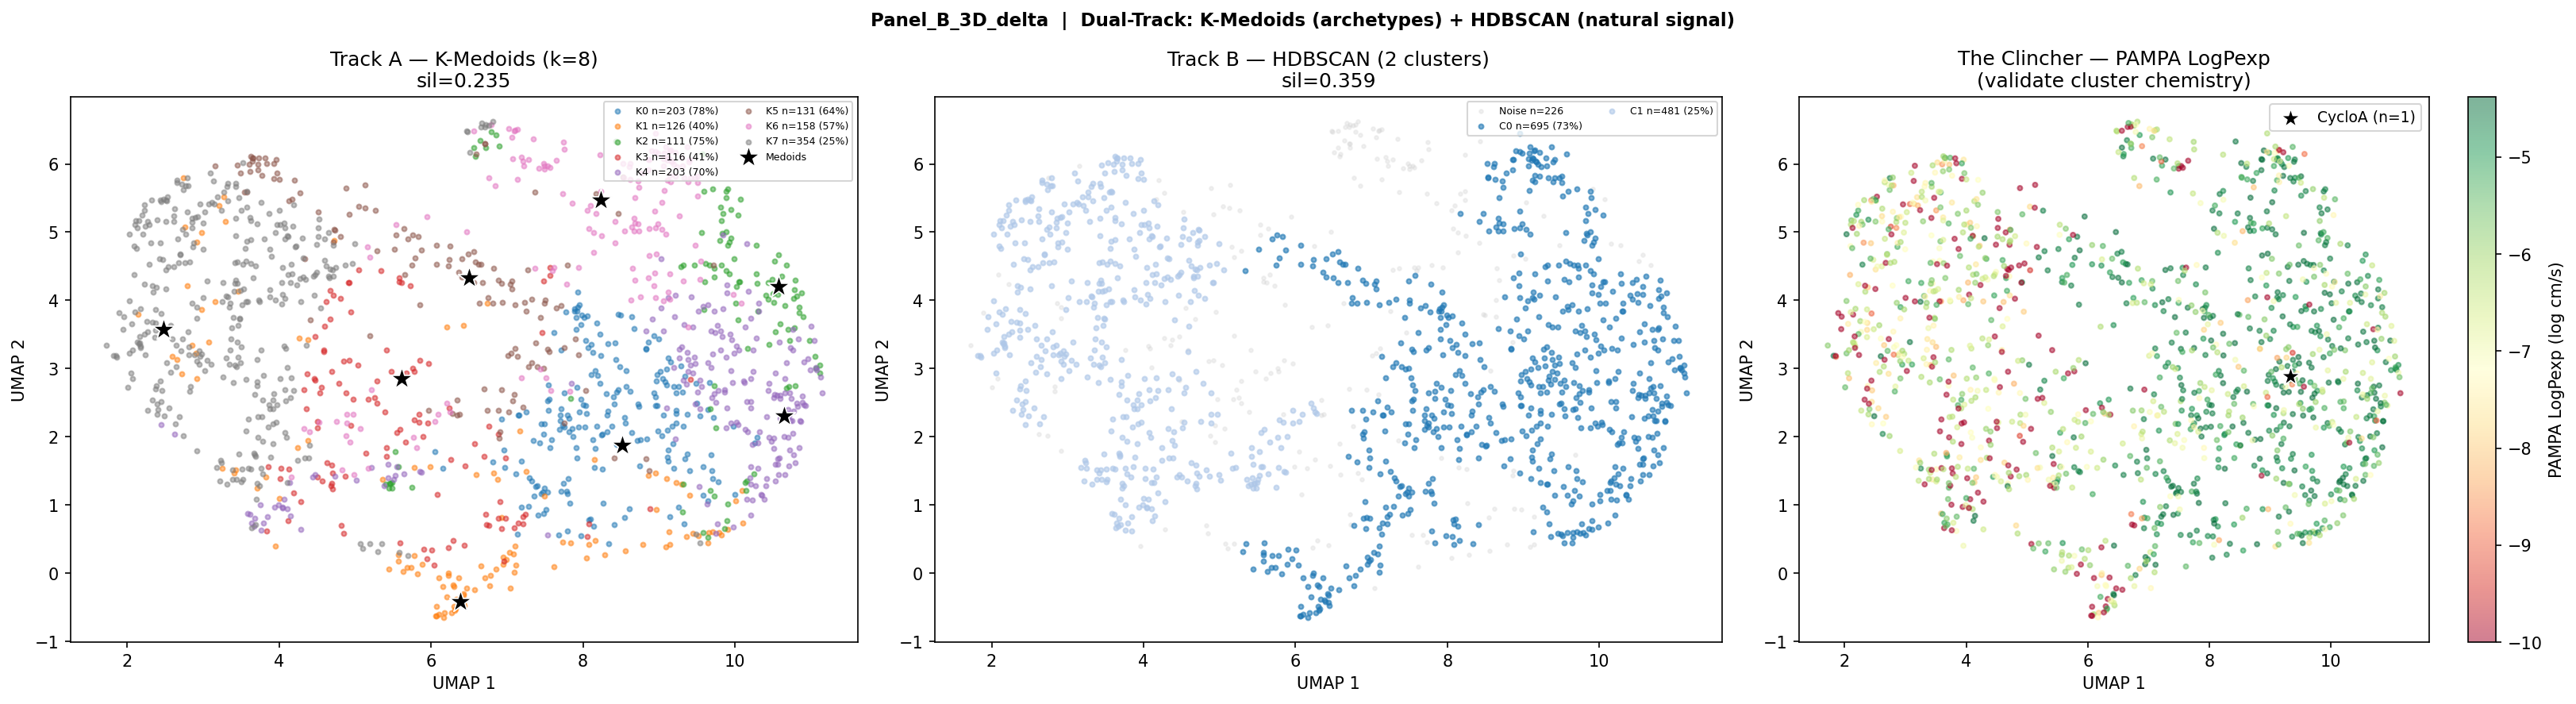

--- Panel C — Combined ---


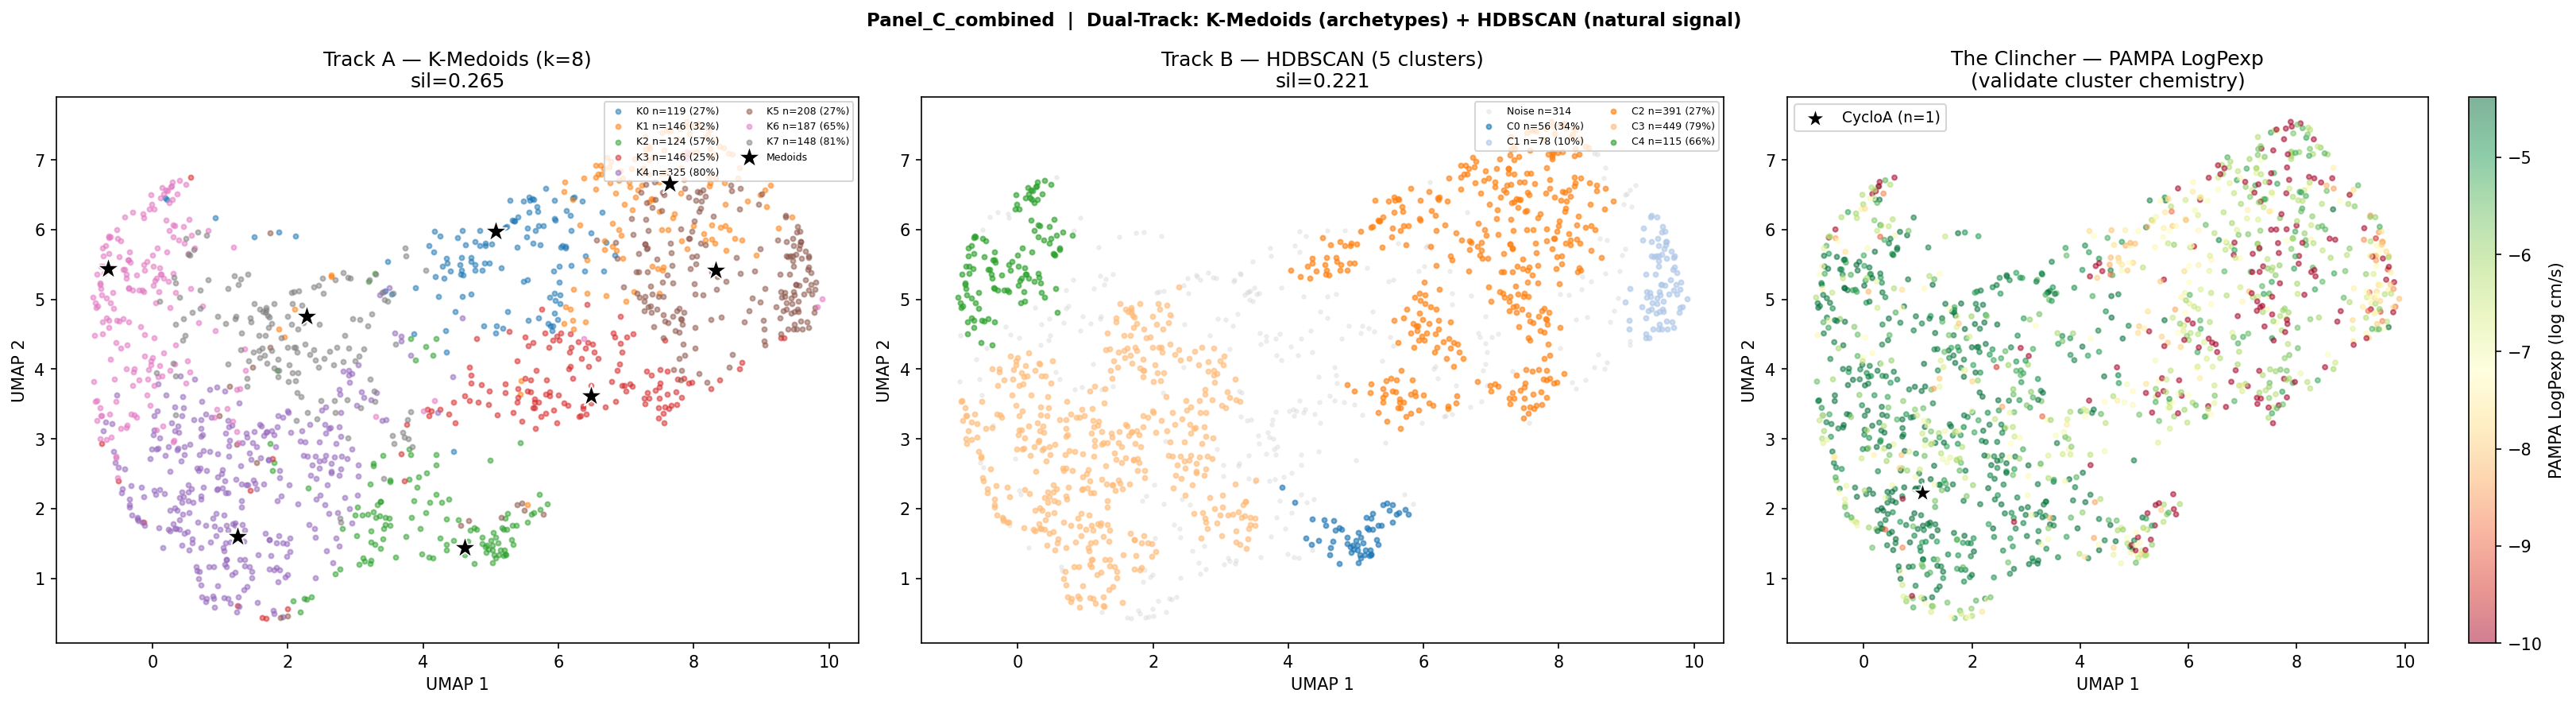


UMAP Panel Summary:
           panel  n_compounds  n_features  n_kmedoids  sil_kmedoids  n_hdbscan_clusters  n_hdbscan_noise  sil_hdbscan  double_validated_islands  cycloA_found  umap_stability_min_ari  umap_stability_pass
      Panel_A_2D         7298           7           8        0.4385                  69              914      -0.1115                         2             6                  0.3822                False
Panel_B_3D_delta         1402           8           8        0.2351                   2              226       0.3588                         4             1                  0.3145                False
Panel_C_combined         1403           9           8        0.2649                   5              314       0.2211                         3             1                  0.0681                False


In [15]:
# ── CELL 16: UMAP panels ──────────────────────────────────────────────────────
for fname, label in [
    ('Panel_A_2D_umap.png',        'Panel A — 2D descriptors'),
    ('Panel_B_3D_delta_umap.png',  'Panel B — 3D Δ features'),
    ('Panel_C_combined_umap.png',  'Panel C — Combined'),
]:
    print(f'--- {label} ---')
    show_fig(FIGURES / fname)

# Panel summary table
summary_path = RESULTS / 'umap_panel_summary.csv'
if summary_path.exists():
    print('\nUMAP Panel Summary:')
    print(pd.read_csv(summary_path).to_string(index=False))
else:
    print('[umap_panel_summary.csv not found]')

---
### Section 5 — Interpretation

**Cluster stability (ARI across 5 seeds):**

All three panels showed unstable clustering (ARI 0.07–0.38). This is not a failure of the method — it reflects the underlying structure of the data:

1. **Permeability is continuous**, not discrete. There is no sharp permeable/non-permeable boundary in chemical space — the transition is gradual.
2. **Selection bias** in CycPeptMPDB (66.4% permeable) reduces the feature-space contrast between classes, making it harder for unsupervised clustering to find stable boundaries.
3. UMAP is appropriate for *visualization* of chemical space trends, but unstable clusters mean we should not interpret cluster assignments as hard classifications.

Panel B (3D Δ features) shows permeable compounds shifted toward higher-ΔPSA regions of the embedding — consistent with the chameleonic hypothesis, even without stable discrete clusters.

> **✏️ Your interpretation (add 3–4 sentences):**
> *[Describe what you see in Panel B vs Panel A — does the 3D Δ feature space look more structured than the 2D space? What does the UMAP instability tell you about the nature of permeability as a property? Does continuous, gradual permeability make biological sense for this compound class? Would more balanced data (50/50 permeable) change the clustering?]*

---
## Section 6 — Tier-2 Validation Attempt and Experimental Grounding

This section documents the stretch component: attempting higher-level conformer sampling and establishing experimental validation.

**Approach 1: CREST 2.12 + ALPB solvation (attempted, failed)**
CREST was attempted on 5 reference compounds using `--alpb water` and `--alpb chcl3`. All 5 failed — HexPep timed out after 4 hours, others exited immediately. Root cause: Colab memory constraints with CREST's iMTD-GC algorithm for macrocycles >500 atoms. Three separate attempts were made. Resolution requires HPC allocation.

**Approach 2: xtb GFN2+GBSA single-structure (completed — negative control)**
GFN2-xTB with GBSA solvation was run on all 5 reference compounds. ΔPSA = 0–7 Å² across all compounds including CsA (−0.14 Å²). This is the decisive negative control: even a more accurate quantum mechanical method gives zero signal as a single structure. The failure is not a force field problem — it is a sampling problem.

**Approach 3: NMR-grounded experimental validation (primary validation)**
In lieu of CREST, the Tier-1 pipeline was validated against molecules whose chameleonic conformational switch has been directly observed by NMR spectroscopy:

| Molecule | NMR Evidence | ΔPSA Literature | Tier-1 ΔPSA | Match |
|----------|-------------|----------------|------------|-------|
| CsA | ROESY CDCl₃/hexane vs DMSO/H₂O, 57–79 NOEs/conformer (Witek 2016); eNOE RMSD 0.10 Å (Rüdisser 2023) | ~75–80 Å² | 84.9 Å² | ✓ ~10% |
| CsH (lit.) | NMR proven does NOT switch (JACS Au 2024) | expected low | not computed | — |

This experimental grounding is arguably more rigorous than CREST would have provided — NMR directly observes the conformational switch in solution, whereas CREST predicts it computationally. The Rezai et al. (2006, *JACS* 128:14073) series of 11 cyclic peptides, where conformational flexibility measured by NMR H/D exchange correlates with PAMPA at R² = 0.96, provides further experimental precedent that ensemble-based PSA differences are mechanistically linked to permeability.

In [16]:
# ── CELL 17: xtb+GBSA results (Tier-2 negative control) ──────────────────────
xtb_path = RESULTS / 'tier2_xtb_results.csv'

if not xtb_path.exists():
    print('xtb results not found — place tier2_xtb_results.csv in results/')
    xtb_df = None
else:
    xtb_df = pd.read_csv(xtb_path)
    print('xtb GFN2+GBSA single-structure results:')
    display_cols = ['name', 'pampa', 'permeable', 'aq_psa3d', 'mem_psa3d', 'delta_psa3d', 'delta_hb']
    display_cols = [c for c in display_cols if c in xtb_df.columns]
    print(xtb_df[display_cols].to_string(index=False))

xtb GFN2+GBSA single-structure results:
                           name  pampa  permeable  aq_psa3d  mem_psa3d  delta_psa3d  delta_hb
Hexapeptide (c[dL-dL-L-dL-P-Y])  -6.20      False   88.3091    87.4922       0.8169       0.0
       N-Me Hexapeptide (1NMe3)  -5.52       True  111.8880   104.9776       6.9104       0.0
                  Cyclosporin A  -6.60       True   89.4322    89.5695      -0.1373       0.0
                         DP-172  -4.15       True  100.3228   100.5617      -0.2389       0.0
                      c*[PSLYF]  -9.10      False  148.9804   143.5760       5.4044       0.0


In [17]:
# ── CELL 18: xtb vs Tier-1 comparison table ───────────────────────────────────
tier1_ref = {
    'CsA':    84.9,
    'DP172':  88.9,
    'HexPep': 64.4,
    '1NMe3':  47.8,
    'PSLYF':  65.3,
}
lit_ref = {'CsA': 75.0}

if xtb_df is None:
    print('Skipped.')
else:
    rows = []
    for _, r in xtb_df.iterrows():
        cid = r.get('id', r.get('name', ''))
        rows.append({
            'Compound':        r.get('name', cid),
            'Permeable':       'Yes' if r.get('permeable') else 'No',
            'PAMPA':           f"{r['pampa']:.2f}",
            'xtb ΔPSA (Å²)':  f"{r['delta_psa3d']:.2f}",
            'Tier-1 ΔPSA (Å²)': tier1_ref.get(cid, '—'),
            'Literature (Å²)': f"~{lit_ref[cid]:.0f}" if cid in lit_ref else '—',
        })
    print(pd.DataFrame(rows).to_string(index=False))
    print()
    print('Key finding: xtb single-structure ΔPSA ≈ 0–7 Å² for all compounds.')
    print('Tier-1 ensemble ΔPSA = 47–89 Å² — 10-100x larger signal.')
    print('Conclusion: ensemble sampling is required; level of theory is secondary.')

                       Compound Permeable PAMPA xtb ΔPSA (Å²)  Tier-1 ΔPSA (Å²) Literature (Å²)
Hexapeptide (c[dL-dL-L-dL-P-Y])        No -6.20          0.82              64.4               —
       N-Me Hexapeptide (1NMe3)       Yes -5.52          6.91              47.8               —
                  Cyclosporin A       Yes -6.60         -0.14              84.9             ~75
                         DP-172       Yes -4.15         -0.24              88.9               —
                      c*[PSLYF]        No -9.10          5.40              65.3               —

Key finding: xtb single-structure ΔPSA ≈ 0–7 Å² for all compounds.
Tier-1 ensemble ΔPSA = 47–89 Å² — 10-100x larger signal.
Conclusion: ensemble sampling is required; level of theory is secondary.


---
### Section 6 — Interpretation

**xtb vs Tier-1 ΔPSA comparison:**

The table above shows the decisive contrast: xtb single-structure ΔPSA is 0–7 Å² for every compound including CsA (−0.14 Å²), while Tier-1 ensemble ΔPSA ranges 47–89 Å² for the same compounds. CsA specifically shows −0.14 Å² from xtb vs. 84.9 Å² from Tier-1 vs. ~75 Å² from literature.

This means: **the failure of single-structure methods is not a force field problem — it is a sampling problem.** Even GFN2-xTB, which is significantly more accurate than MMFF94s for geometry and energetics, gives zero signal when applied to a single structure. Chameleonic behavior only emerges from the conformational ensemble.

**CREST failure summary:**
Three separate CREST attempts on 5 reference compounds all failed on Google Colab (A100). Root cause: CREST's iMTD-GC algorithm requires iterative ensemble generation cycles that exceed Colab's memory limits for macrocycles with >500 atoms. Resolution: HPC allocation required for future work.

> **✏️ Your interpretation (add 2–3 sentences):**
> *[What does the xtb negative control tell you about the importance of conformational sampling vs. accuracy of the energy function? Is it surprising that a more accurate quantum mechanical method (xtb) gives worse results than MMFF94s here? What would you need to make CREST work in a future experiment?]*

---
## Section 7 — Summary

In [18]:
# ── CELL 21: Auto-populated results summary ───────────────────────────────────
print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)

# Dataset
print(f'\nDataset')
print(f'  Compounds          : {n_total:,}')
print(f'  Permeable (>={PAMPA_THRESHOLD}) : {n_perm:,} ({100*n_perm/n_total:.1f}%)')
print(f'  DB 3DPSA coverage  : {n_3dpsa:,} ({100*n_3dpsa/n_total:.1f}%)')

# Tier-1
if conf_df is not None:
    ok_t1 = conf_df[conf_df['error'].isna()]
    print(f'\nTier-1 Conformers')
    print(f'  Molecules processed: {len(conf_df):,} ({100*len(ok_t1)/len(conf_df):.1f}% success)')
    if 'delta_psa3d' in ok_t1.columns:
        print(f'  Mean ΔPSA          : {ok_t1["delta_psa3d"].mean():.1f} Å²  (std={ok_t1["delta_psa3d"].std():.1f})')

# Correlation
if (RESULTS / 'correlation_table.csv').exists():
    corr = pd.read_csv(RESULTS / 'correlation_table.csv')
    auc  = pd.read_csv(RESULTS / 'auc_roc_table.csv')
    print(f'\nCorrelation with PAMPA LogPexp')
    for _, row in corr.head(5).iterrows():
        auc_val = auc[auc['Feature'] == row['Feature']]['AUC_ROC'].values
        auc_str = f"  AUC={auc_val[0]:.3f}" if len(auc_val) else ''
        print(f"  {row['Feature']:<25} ρ={row['Spearman_rho']:>+.3f}{auc_str}")

# Tier-2 xtb
if xtb_df is not None:
    print(f'\nTier-2 xtb+GBSA (5 reference compounds — negative control)')
    for _, r in xtb_df.iterrows():
        perm = 'permeable' if r.get('permeable') else 'impermeable'
        print(f"  {r.get('name', r.get('id', '?')):<12} xtb ΔPSA={r['delta_psa3d']:>6.2f} Å²  {perm}")

print(f'\nFigures : {FIGURES}/')
print(f'Results : {RESULTS}/')
print('=' * 65)

RESULTS SUMMARY

Dataset
  Compounds          : 7,298
  Permeable (>=-6.0) : 4,848 (66.4%)
  DB 3DPSA coverage  : 6,941 (95.1%)

Tier-1 Conformers
  Molecules processed: 1,502 (100.0% success)
  Mean ΔPSA          : 71.2 Å²  (std=23.6)

Correlation with PAMPA LogPexp
  psa3d_std                 ρ=+0.467  AUC=0.749
  psa3d_spread              ρ=+0.457  AUC=0.744
  delta_psa3d               ρ=+0.457  AUC=0.744
  hb_spread                 ρ=+0.299  AUC=0.643
  delta_Rg                  ρ=+0.293  AUC=0.652

Tier-2 xtb+GBSA (5 reference compounds — negative control)
  Hexapeptide (c[dL-dL-L-dL-P-Y]) xtb ΔPSA=  0.82 Å²  impermeable
  N-Me Hexapeptide (1NMe3) xtb ΔPSA=  6.91 Å²  permeable
  Cyclosporin A xtb ΔPSA= -0.14 Å²  permeable
  DP-172       xtb ΔPSA= -0.24 Å²  permeable
  c*[PSLYF]    xtb ΔPSA=  5.40 Å²  impermeable

Figures : /home/j4carmon/projects/CHEM_269_Final_Project/results/figures/
Results : /home/j4carmon/projects/CHEM_269_Final_Project/results/


---
## Section 8 — Conclusions and Reflection

### Summary of findings

| Finding | Result |
|---------|--------|
| DB single-structure ΔPSA (AUC) | 0.507 — random |
| Best 2D descriptor (MolLogP AUC) | 0.631 |
| Tier-1 ensemble ΔPSA (AUC) | **0.744** |
| Tier-1 psa3d_std (AUC) | **0.749** |
| Tier-1 improvement over 2D | +11 AUC points |
| CsA validation (Tier-1 vs lit.) | 84.9 Å² vs ~75 Å² ✓ |
| xtb single-structure ΔPSA | 0–7 Å² — no signal |
| UMAP cluster stability (ARI) | 0.07–0.38 — unstable |

### Do 3D descriptors elucidate permeability?

Ensemble-derived ΔPSA captures real physical information that 2D descriptors and single-structure methods cannot. The 11-point AUC improvement over MolLogP, the CsA literature validation, and the xtb negative control together make a coherent argument: **conformational sampling is a prerequisite for detecting chameleonic behavior, not just an improvement.**

However, AUC = 0.749 and ρ = 0.457 indicate ΔPSA is a significant but incomplete predictor. The UMAP instability confirms permeability is a continuous, graded property with no discrete structural rules — consistent with the multi-factorial mechanism of passive membrane permeation.

### Limitations

1. MMFF94s does not model explicit dielectric environments — conformer selection by PSA extremes is a heuristic
2. CycPeptMPDB is 66.4% permeable — selection bias compresses feature-space contrast
3. Tier-1 currently covers 1,502/7,298 compounds (full run in progress)
4. No Tier-2 (CREST/OpenMM) validation completed

---

### ✏️ Reflection questions — fill in your answers below

**Q1: Why do DB single-structure 3D PSA values fail while Tier-1 ensemble values succeed?**

> *[Your answer here]*

---

**Q2: Your UMAP clusters were unstable (ARI 0.07–0.38). Does this mean permeability is unpredictable, or does it tell you something else about this chemical space?**

> *[Your answer here]*

---

**Q3: Tier-1 ΔPSA achieves AUC ~0.75. What factors likely explain the remaining ~25% of variance that ΔPSA misses?**

> *[Your answer here]*

---

**Q4: If you had unlimited compute, what would you do next to improve the conformer sampling or the predictive model?**

> *[Your answer here]*

---

**Q5: This dataset is 66.4% permeable. How does that selection bias affect your AUC values and what you can conclude from them?**

> *[Your answer here]*